# Introduction au ML — Séance 11 (Capstone)
## Un projet de bout en bout : prédire le paludisme

**Dr. El Hadji Bassirou TOURÉ** · DMI · FST · UCAD

***

Ce notebook est le **projet de synthèse** du cours. On y mène un projet ML complet, comme dans
une compétition de science des données (type **Zindi**), en mobilisant toutes les séances :
cadrer → explorer → préparer (sans fuite) → comparer → régler → évaluer honnêtement →
interpréter. La leçon centrale vous attend à l'étape 7.

**Durée estimée : 1h30.** Exécuter les cellules dans l'ordre.

## Étape 0 — Mise en place

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
print("Outils prêts.")

Outils prêts.


In [2]:
# Générateur officiel DataSANTÉ-221 (ne pas modifier)
def generate_datasante221(n=10_000, seed=221):
    rng = np.random.default_rng(seed)
    age = np.clip(rng.gamma(2.5, 14, n), 5, 85).round(0).astype(int)
    glycemie = np.clip(rng.normal(5.5 + 0.05*age, 1.8), 3.0, 18.0).round(1)
    hemoglobine = np.clip(rng.normal(12.5 - 0.02*age, 1.5), 6.0, 17.0).round(1)
    fievre = np.clip(rng.normal(37.5, 0.9, n), 36.0, 41.5).round(1)
    saison = rng.choice([0, 1], size=n, p=[0.55, 0.45])
    duree = (1.0 + 0.05*age + 0.6*glycemie - 0.3*hemoglobine
             + 1.5*saison + rng.normal(0, 1.8, n)).clip(0.5, 30).round(1)
    proba_palu = 1/(1+np.exp(-(-3 + 1.5*saison + 0.8*(fievre>38.5))))
    palu = (rng.uniform(0,1,n) < proba_palu).astype(int)
    return pd.DataFrame({'age':age,'glycemie':glycemie,'hemoglobine':hemoglobine,
                         'fievre':fievre,'saison':saison,'duree_hospit_j':duree,'paludisme':palu})
df = generate_datasante221()
df.head()

,age,glycemie,hemoglobine,fievre,saison,duree_hospit_j,paludisme
0,47,9.3,11.8,38.0,0,3.8,0
1,18,5.1,13.0,39.5,1,0.5,0
2,56,7.2,9.5,37.1,1,6.5,0
3,36,6.8,10.4,36.1,1,5.0,1
4,9,6.2,12.0,37.9,0,2.2,0


## Étape 1 — Cadrer le problème

Avant tout code : quelle tâche, quelle métrique, quelle référence, quelle contrainte ?

In [3]:
# La cible et sa prévalence
print("nombre de patients :", len(df))
print("variables :", [c for c in df.columns if c != 'paludisme'])
print(f"prévalence du paludisme : {df['paludisme'].mean()*100:.1f}%")
print()
print("-> tâche    : classification binaire")
print("-> données  : déséquilibrées (11.8% de positifs) => l'accuracy sera trompeuse")
print("-> métrique : AUC + rappel (repérer les malades)")
print("-> métier   : rater un malade (faux négatif) est plus grave qu'une fausse alerte")

nombre de patients : 10000
variables : ['age', 'glycemie', 'hemoglobine', 'fievre', 'saison', 'duree_hospit_j']
prévalence du paludisme : 11.8%

-> tâche    : classification binaire
-> données  : déséquilibrées (11.8% de positifs) => l'accuracy sera trompeuse
-> métrique : AUC + rappel (repérer les malades)
-> métier   : rater un malade (faux négatif) est plus grave qu'une fausse alerte


## Étape 2 — Explorer les données (EDA)

Comprendre avant de modéliser : repérer les facteurs de risque à l'œil nu.

In [4]:
# Statistiques des variables numériques
df[['age','glycemie','hemoglobine','fievre','duree_hospit_j']].describe().round(1)

,age,glycemie,hemoglobine,fievre,duree_hospit_j
count,10000.0,10000.0,10000.0,10000.0,10000.0
mean,34.5,7.2,11.8,37.5,4.3
std,20.4,2.0,1.6,0.9,2.7
min,5.0,3.0,6.1,36.0,0.5
25%,18.0,5.8,10.7,36.9,2.2
50%,31.0,7.2,11.8,37.5,4.1
75%,47.0,8.6,12.8,38.1,6.1
max,85.0,16.6,17.0,40.8,15.3


In [5]:
# Taux de paludisme par saison et par niveau de fièvre
print("paludisme par saison :")
for s, nom in [(0, 'sèche'), (1, 'pluies')]:
    sub = df[df['saison'] == s]
    print(f"  saison {nom:7} : {sub['paludisme'].mean()*100:5.1f}%  (n={len(sub)})")

print("\npaludisme par fièvre :")
for f, nom in [(False, 'fièvre <= 38.5'), (True, 'fièvre > 38.5')]:
    sub = df[(df['fievre'] > 38.5) == f]
    print(f"  {nom:14} : {sub['paludisme'].mean()*100:5.1f}%  (n={len(sub)})")

paludisme par saison :
  saison sèche   :   5.1%  (n=5549)
  saison pluies  :  20.1%  (n=4451)

paludisme par fièvre :
  fièvre <= 38.5 :  10.6%  (n=8748)
  fièvre > 38.5  :  20.1%  (n=1252)


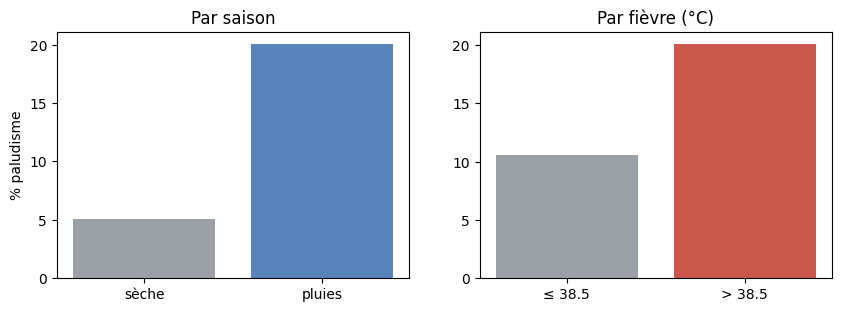

In [6]:
# Visualiser ces deux facteurs
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
sa = [df[df['saison']==s]['paludisme'].mean()*100 for s in [0,1]]
axes[0].bar(['sèche','pluies'], sa, color=['#8a8f98','#3b6fb0'], alpha=0.85)
axes[0].set_ylabel("% paludisme"); axes[0].set_title("Par saison")
fv = [df[(df['fievre']>38.5)==f]['paludisme'].mean()*100 for f in [False,True]]
axes[1].bar(['≤ 38.5','> 38.5'], fv, color=['#8a8f98','#c0392b'], alpha=0.85)
axes[1].set_title("Par fièvre (°C)")
plt.show()

**Lecture.** La saison des pluies (20,1 % vs 5,1 %) et la forte fièvre (20,1 % vs 10,6 %)
ressortent nettement. Le modèle final devra s'appuyer sur ces variables — on le vérifiera.

## Étape 3 — Sceller le test, préparer sans fuite

La toute première opération : mettre le test de côté. Puis préparer dans un **pipeline**.

In [7]:
from sklearn.model_selection import train_test_split

feats = ['age','glycemie','hemoglobine','fievre','saison','duree_hospit_j']
X = df[feats].values
y = df['paludisme'].values

# Sceller 20% comme test, AVANT tout, en stratifiant
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"train : {len(X_tr)}  |  test scellé : {len(X_te)}")
print(f"prévalence  train {y_tr.mean()*100:.1f}%  /  test {y_te.mean()*100:.1f}%  (préservée)")

train : 8000  |  test scellé : 2000
prévalence  train 11.8%  /  test 11.8%  (préservée)


In [8]:
# Préparation + modèle dans UN pipeline : la standardisation sera réapprise à chaque pli
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

modele_logistique = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000)),
])
print("pipeline prêt : la standardisation est encapsulée (anti-fuite).")

pipeline prêt : la standardisation est encapsulée (anti-fuite).


## Étape 4 — La baseline

Une référence triviale, à battre. Ici : prédire toujours la classe majoritaire.

In [9]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
print(f"baseline (classe majoritaire) : accuracy = {baseline.score(X_tr, y_tr):.4f}")
print("-> 88% d'accuracy SANS rien apprendre : un piège que l'on retrouvera à l'étape 7.")

baseline (classe majoritaire) : accuracy = 0.8824
-> 88% d'accuracy SANS rien apprendre : un piège que l'on retrouvera à l'étape 7.


## Étape 5 — Comparer les modèles loyalement

Toutes les familles du cours, même validation croisée stratifiée, même métrique (AUC).

In [10]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

modeles = {
    "Régression logistique": modele_logistique,
    "Arbre de décision":     DecisionTreeClassifier(max_depth=5, random_state=0),
    "Random Forest":         RandomForestClassifier(n_estimators=300, random_state=0),
    "Gradient Boosting":     GradientBoostingClassifier(random_state=0),
    "Réseau (MLP 16-8)":     Pipeline([("sc", StandardScaler()),
                                       ("clf", MLPClassifier(hidden_layer_sizes=(16,8),
                                               max_iter=1000, random_state=0))]),
}

print(f"{'modèle':<24}{'AUC CV (moy ± écart)'}")
for nom, m in modeles.items():
    sc = cross_val_score(m, X_tr, y_tr, cv=cv, scoring="roc_auc")
    print(f"{nom:<24}{sc.mean():.4f} ± {sc.std():.4f}")

modèle                  AUC CV (moy ± écart)


Régression logistique   0.6897 ± 0.0160
Arbre de décision       0.6730 ± 0.0153


Random Forest           0.6676 ± 0.0096


Gradient Boosting       0.6906 ± 0.0200


Réseau (MLP 16-8)       0.6884 ± 0.0242


**Lecture.** Les modèles se tiennent dans un mouchoir (AUC ≈ 0,67–0,69). Le gradient boosting
mène de peu. Conformément aux Séances 8 et 10, sur ce tabulaire, le complexe n'écrase pas le
simple. On retient le gradient boosting comme candidat à régler.

## Étape 6 — Régler le meilleur candidat

Recherche d'hyperparamètres en validation croisée. Le test reste scellé.

In [11]:
from sklearn.model_selection import GridSearchCV

grille = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3],
    "learning_rate": [0.05, 0.1],
}
gs = GridSearchCV(GradientBoostingClassifier(random_state=0),
                  grille, cv=cv, scoring="roc_auc", n_jobs=-1)
gs.fit(X_tr, y_tr)

print("meilleurs hyperparamètres :", gs.best_params_)
print(f"AUC CV du meilleur réglage : {gs.best_score_:.4f}")
modele_final = gs.best_estimator_

meilleurs hyperparamètres : {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
AUC CV du meilleur réglage : 0.6972


## Étape 7 — Évaluer sur le test scellé (le moment de vérité)

On ouvre le test UNE seule fois. L'AUC est honnête... mais regardons ce que le modèle prédit
vraiment.

In [12]:
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

proba = modele_final.predict_proba(X_te)[:, 1]
pred  = modele_final.predict(X_te)

print(f"AUC test      : {roc_auc_score(y_te, proba):.4f}")
print(f"accuracy test : {accuracy_score(y_te, pred):.4f}")
print("\nTout semble bien... vraiment ?")

AUC test      : 0.7321
accuracy test : 0.8820

Tout semble bien... vraiment ?


In [13]:
# La matrice de confusion révèle la vérité
cm = confusion_matrix(y_te, pred)
print("matrice de confusion (seuil 0.5) :")
print(f"              prédit sain   prédit palu")
print(f"  réel sain      {cm[0,0]:5d}        {cm[0,1]:4d}")
print(f"  réel palu      {cm[1,0]:5d}        {cm[1,1]:4d}")
print(f"\nvrais positifs (malades détectés) : {cm[1,1]}")
print(f"faux négatifs (malades MANQUÉS)   : {cm[1,0]}")

matrice de confusion (seuil 0.5) :
              prédit sain   prédit palu
  réel sain       1764           1
  réel palu        235           0

vrais positifs (malades détectés) : 0
faux négatifs (malades MANQUÉS)   : 235


**LA LEÇON DU CAPSTONE.** Le modèle « à 88 % d'accuracy » ne prédit **jamais** « paludisme » :
0 vrai positif, 235 malades manqués. Il a appris à dire « sain » à tout le monde — exactement
la baseline. **L'accuracy, gonflée par la classe majoritaire, masquait un échec complet.**

Le remède : abaisser le seuil de décision pour attraper des malades.

In [14]:
# Abaisser le seuil : favoriser le rappel (santé : ne pas rater de malades)
from sklearn.metrics import precision_score, recall_score

for seuil in [0.5, 0.3, 0.2, 0.15]:
    p = (proba >= seuil).astype(int)
    print(f"seuil {seuil:.2f} : précision = {precision_score(y_te, p, zero_division=0):.3f}, "
          f"rappel = {recall_score(y_te, p):.3f}")

seuil 0.50 : précision = 0.000, rappel = 0.000
seuil 0.30 : précision = 0.351, rappel = 0.140
seuil 0.20 : précision = 0.260, rappel = 0.285
seuil 0.15 : précision = 0.210, rappel = 0.711


**Lecture.** Au seuil 0,5, rappel nul. En l'abaissant, on récupère du rappel (on attrape des
malades) au prix de la précision (plus de fausses alertes). Le bon seuil découle de la
contrainte métier de l'étape 1 : en santé, mieux vaut une fausse alerte qu'un malade manqué.

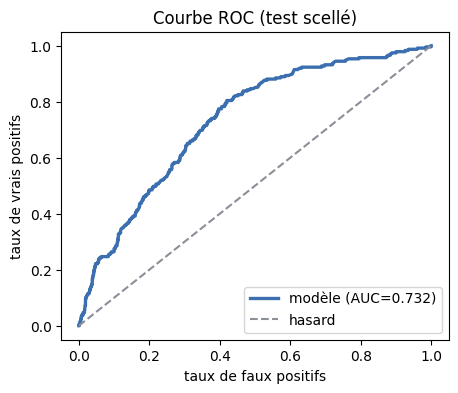

In [15]:
# La courbe ROC : tous les seuils d'un coup
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_te, proba)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color="#3b6fb0", lw=2.4, label=f"modèle (AUC={roc_auc_score(y_te,proba):.3f})")
ax.plot([0,1],[0,1], "--", color="#8a8f98", label="hasard")
ax.set_xlabel("taux de faux positifs"); ax.set_ylabel("taux de vrais positifs")
ax.legend(); ax.set_title("Courbe ROC (test scellé)")
plt.show()

## Étape 8 — Interpréter le modèle

Les variables importantes doivent recouper l'EDA — gage de confiance.

importance des variables :
  saison           0.632
  fievre           0.168
  duree_hospit_j   0.070
  glycemie         0.064
  age              0.035
  hemoglobine      0.031


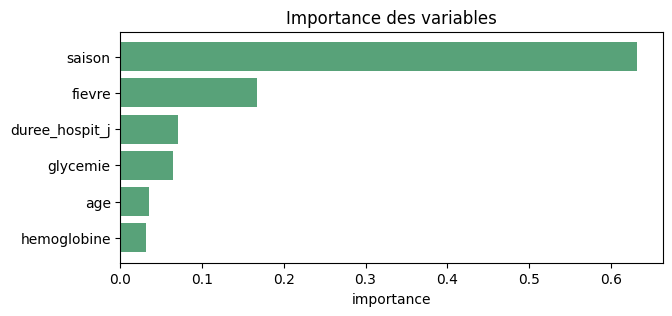

In [16]:
# Importance des variables du modèle final
imp = modele_final.feature_importances_
ordre = np.argsort(imp)[::-1]
print("importance des variables :")
for i in ordre:
    print(f"  {feats[i]:<16} {imp[i]:.3f}")

fig, ax = plt.subplots(figsize=(7, 3))
o = np.argsort(imp)
ax.barh([feats[i] for i in o], [imp[i] for i in o], color="#2e8b57", alpha=0.8)
ax.set_xlabel("importance"); ax.set_title("Importance des variables")
plt.show()

**Lecture.** Le modèle s'appuie d'abord sur la **saison** (0,63), puis la **fièvre** (0,17) —
exactement les facteurs repérés à l'EDA. Cette cohérence est rassurante : le modèle a capté des
liens réels. On peut l'expliquer à un médecin : « le risque dépend d'abord de la saison, puis
de la fièvre ».

## Mini-défi — Votre tour de praticien

À partir de tout ce qui précède, **choisissez et justifiez** un seuil de décision pour un
déploiement en centre de santé, en supposant qu'on dispose des moyens de tester 20 % des
patients. Calculez, à ce seuil, combien de malades seraient détectés et combien de fausses
alertes seraient générées sur le test.

In [ ]:
# Votre seuil justifié, et son bilan (vrais positifs / faux positifs)

## Synthèse du projet — à compléter

1. On a d'abord **..........** le problème (tâche, métrique, baseline, contrainte).
2. L'**..........** a révélé deux facteurs : la saison et la fièvre.
3. On a **..........** le test avant tout, et préparé dans un **..........** (anti-fuite).
4. On a comparé les modèles en **..........** stratifiée, puis **..........** le meilleur.
5. Sur le test scellé, l'accuracy de 88 % était **..........** : 0 malade détecté. La vraie
   mesure était l'**..........** et le **..........**.
6. En abaissant le **..........**, on a récupéré du rappel — un choix **..........**.
7. L'**..........** des variables (saison, fièvre) recoupait l'EDA : le modèle est cohérent.

**Bravo : vous avez mené un projet de Machine Learning de bout en bout.**